# Semana 5 - Dia 3: Segmentacao Financeira Aplicada

Objetivo: construir um pipeline completo de segmentacao e risco com dados financeiros reais.

Este notebook cobre:
- carga e validacao dos dados
- feature engineering de negocio
- classificacao de risco de estouro semanal
- segmentacao por clustering
- interpretacao e recomendacoes acionaveis

## Roteiro
1. Setup
2. Descoberta e carga dos dados
3. Preparacao e features
4. Modelo de risco semanal (classificacao)
5. Segmentacao por clustering
6. Perfil dos clusters e plano de acao

In [15]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup OK')

Setup OK


In [16]:
import os

# Localiza automaticamente o banco do projeto financeiro
# Usa caminho absoluto a partir do diretorio do notebook para evitar problemas de CWD
try:
    notebook_dir = Path(__file__).resolve().parent
except NameError:
    notebook_dir = Path(os.getcwd()).resolve()

# Sobe ate achar a raiz do workspace (contem a pasta semana-04-consolidacao)
workspace_root = notebook_dir
for _ in range(6):
    if (workspace_root / 'semana-04-consolidacao').exists():
        break
    workspace_root = workspace_root.parent

print(f'Notebook dir   : {notebook_dir}')
print(f'Workspace root : {workspace_root}')

candidates = [
    workspace_root / 'semana-04-consolidacao' / 'ppiaFinanceiro' / 'dados' / 'db' / 'financeiro.db',
    workspace_root / 'semana-04-consolidacao' / 'ppiaFinanceiro' / 'backend' / 'dados' / 'db' / 'financeiro.db',
    workspace_root / 'semana-04-consolidacao' / 'ppiaFinanceiro' / 'backend' / 'data' / 'financeiro.db',
    notebook_dir / 'financeiro.db',
]

print('\nTestando candidatos:')
for c in candidates:
    print(f'  {"OK " if c.exists() else "-- "} {c}')

db_path = next((p for p in candidates if p.exists()), None)

conn = None
if db_path is None:
    print('\nBanco nao encontrado. O notebook usara fallback sintetico.')
else:
    try:
        conn = sqlite3.connect(str(db_path))
        print(f'\nConectado em: {db_path}')
    except sqlite3.Error as e:
        print(f'\nFalha ao conectar no SQLite: {e}')
        conn = None

conn

Notebook dir   : D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-05-ml-nao-supervisionado\notebooks
Workspace root : D:\Professional\Projetos\Github\Aprendizado-IA-2025

Testando candidatos:
  OK  D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-04-consolidacao\ppiaFinanceiro\dados\db\financeiro.db
  --  D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-04-consolidacao\ppiaFinanceiro\backend\dados\db\financeiro.db
  --  D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-04-consolidacao\ppiaFinanceiro\backend\data\financeiro.db
  --  D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-05-ml-nao-supervisionado\notebooks\financeiro.db

Conectado em: D:\Professional\Projetos\Github\Aprendizado-IA-2025\semana-04-consolidacao\ppiaFinanceiro\dados\db\financeiro.db


In [17]:
# Descobre tabelas disponiveis
if conn is not None:
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
    print('Tabelas encontradas:')
    display(tables)
else:
    tables = pd.DataFrame({'name': []})
    print('Sem conexao com banco.')

Tabelas encontradas:


,name
0,categorias_aprendidas
1,lancamentos
2,lancamentos_archive
3,lancamentos_faturas_txt
4,lancamentos_txt
5,lancamentos_xls
6,sqlite_sequence
7,transacoes_openfinance
8,weekly_budgets


## Carga dos dados
O notebook tenta usar tabelas reais (`lancamentos`, `weekly_budgets`).
Se alguma nao existir, cria um dataset sintetico para manter o fluxo completo executavel.

In [18]:
def load_or_synthetic(conn):
    needed_tx = 'lancamentos'
    needed_budget = 'weekly_budgets'

    if conn is not None:
        existing = set(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'])
    else:
        existing = set()

    if needed_tx in existing:
        tx = pd.read_sql(f'SELECT * FROM {needed_tx}', conn)
    else:
        tx = pd.DataFrame()

    if needed_budget in existing:
        budgets = pd.read_sql(f'SELECT * FROM {needed_budget}', conn)
    else:
        budgets = pd.DataFrame()

    if tx.empty:
        n = 2200
        categorias = ['Mercado', 'Lazer', 'Transporte', 'Saude', 'Casa', 'Investimentos']
        fontes = ['PIX', 'Master Fisico', 'Visa Bia', 'Visa Mae', 'Master Virtual']

        data = pd.date_range('2025-01-01', periods=n, freq='D')
        tx = pd.DataFrame({
            'Data': np.random.choice(data, n),
            'Descricao': np.random.choice(['Compra', 'Assinatura', 'Transferencia', 'Farmacia', 'Combustivel'], n),
            'Valor': np.round(np.random.normal(loc=-120, scale=180, size=n), 2),
            'Fonte': np.random.choice(fontes, n),
            'Categoria': np.random.choice(categorias, n),
        })
        tx['MesComp'] = pd.to_datetime(tx['Data']).dt.to_period('M').astype(str)

    # Garante colunas basicas
    rename_map = {
        'data': 'Data',
        'descricao': 'Descricao',
        'valor': 'Valor',
        'fonte': 'Fonte',
        'categoria': 'Categoria'
    }
    tx = tx.rename(columns={k: v for k, v in rename_map.items() if k in tx.columns})

    if 'Data' not in tx.columns:
        tx['Data'] = pd.Timestamp.today()
    if 'Valor' not in tx.columns:
        tx['Valor'] = 0.0
    if 'Categoria' not in tx.columns:
        tx['Categoria'] = 'A definir'
    if 'Fonte' not in tx.columns:
        tx['Fonte'] = 'Desconhecida'

    if budgets.empty:
        # Cria budget sintetico por categoria/pessoa/semana
        persons = ['Luciano', 'Bia', 'Mae']
        weeks = [1, 2, 3, 4, 5]
        meses = pd.period_range('2025-01', '2026-04', freq='M').astype(str)
        rows = []
        for m in meses:
            for p in persons:
                for c in tx['Categoria'].dropna().unique():
                    for w in weeks:
                        rows.append({
                            'month_ref': m,
                            'week_number': w,
                            'category': c,
                            'person': p,
                            'expected_amount': float(np.random.uniform(200, 1800)),
                            'is_recurring': int(np.random.choice([0, 1], p=[0.7, 0.3])),
                            'confidence': float(np.random.uniform(0.55, 0.95))
                        })
        budgets = pd.DataFrame(rows)

    return tx.copy(), budgets.copy()

tx, budgets = load_or_synthetic(conn)
print(f'Transacoes: {tx.shape}')
print(f'Orcamentos semanais: {budgets.shape}')
display(tx.head(3))
display(budgets.head(3))

Transacoes: (3226, 19)
Orcamentos semanais: (564, 12)


,id,MesComp,Fonte,Data,Descricao,Valor,Categoria,data_orig,tipo_cartao,compra_parcelada,parcela_atual,qtd_parcelas,moeda_estrangeira,simbolo_moeda,valor_moeda_estrangeira,cotacao,raw_data,updated_at,created_at
0,1,Janeiro 2025,Visa Bia,2024-12-19,COLIBRI GLORIA,43.36,Compras,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,"{""origin"": ""openfinance"", ""provider_id"": ""00a3...",None,2026-03-24T09:59:58.107552
1,2,Janeiro 2025,Visa Físico,2024-12-19,PG *CAMILA O-CT IRA SI,402.68,Estética,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,"{""origin"": ""openfinance"", ""provider_id"": ""533d...",None,2026-03-24T09:59:58.107584
2,3,Janeiro 2025,Visa Físico,2024-12-19,CANTINHO DA -CT,82.87,Compras,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,"{""origin"": ""openfinance"", ""provider_id"": ""093d...",None,2026-03-24T09:59:58.107602


,id,generated_at,month_ref,week_number,category,source,person,expected_amount,is_recurring,recurring_items,confidence,created_at
0,143,2026-01-13,2026-01,3,Lazer,Master Físico,Usuário,150.08,1,"[""IFD*TF ALIMENTOS E SER""]",None,2026-01-13 22:39:01
1,144,2026-01-13,2026-01,3,Farmácia,Visa Mae,Mãe,80.44,1,"[""DROGASIL2867-CT 01/02""]",None,2026-01-13 22:39:01
2,145,2026-01-13,2026-01,3,Farmácia,Master Virtual,Usuário,119.74,1,"[""DROGARIA NOV*5201801/04""]",None,2026-01-13 22:39:01


In [19]:
# Normalizacao e enriquecimento
tx['Data'] = pd.to_datetime(tx['Data'], errors='coerce', dayfirst=True)
tx = tx.dropna(subset=['Data']).copy()

tx['month_ref'] = tx['Data'].dt.to_period('M').astype(str)
tx['week_number'] = tx['Data'].dt.day.sub(1).floordiv(7).add(1).clip(1, 5)
tx['day_of_week'] = tx['Data'].dt.dayofweek
tx['is_weekend'] = tx['day_of_week'].isin([5, 6]).astype(int)

# Convencao: despesas positivas para facilitar agregacoes
tx['expense_value'] = tx['Valor'].astype(float)
tx['expense_value'] = np.where(tx['expense_value'] < 0, -tx['expense_value'], tx['expense_value'])

def derive_person(source):
    s = str(source).lower()
    if 'bia' in s:
        return 'Bia'
    if 'mae' in s or 'mãe' in s:
        return 'Mae'
    return 'Luciano'

tx['person'] = tx['Fonte'].apply(derive_person)

# Padroniza colunas de budget
rename_budget = {
    'month_ref': 'month_ref',
    'week_number': 'week_number',
    'category': 'category',
    'person': 'person',
    'expected_amount': 'expected_amount',
    'is_recurring': 'is_recurring',
    'confidence': 'confidence'
}
budgets = budgets.rename(columns={c: rename_budget.get(c, c) for c in budgets.columns})

required_b = ['month_ref', 'week_number', 'category', 'person', 'expected_amount']
for c in required_b:
    if c not in budgets.columns:
        budgets[c] = np.nan

budgets['week_number'] = pd.to_numeric(budgets['week_number'], errors='coerce').fillna(1).astype(int)
budgets['expected_amount'] = pd.to_numeric(budgets['expected_amount'], errors='coerce').fillna(0.0)
budgets['is_recurring'] = pd.to_numeric(budgets.get('is_recurring', 0), errors='coerce').fillna(0).astype(int)
budgets['confidence'] = pd.to_numeric(budgets.get('confidence', 0.7), errors='coerce').fillna(0.7)

tx[['Data', 'month_ref', 'week_number', 'Categoria', 'person', 'expense_value']].head()

C:\Users\luti_\AppData\Local\Temp\ipykernel_18860\2599996975.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  tx['Data'] = pd.to_datetime(tx['Data'], errors='coerce', dayfirst=True)


,Data,month_ref,week_number,Categoria,person,expense_value
0,2024-12-19,2024-12,3,Compras,Bia,43.36
1,2024-12-19,2024-12,3,Estética,Luciano,402.68
2,2024-12-19,2024-12,3,Compras,Luciano,82.87
3,2024-12-19,2024-12,3,Compras,Luciano,41.24
4,2024-12-19,2024-12,3,Compras,Bia,110.91


In [20]:
# Agregacao semanal por pessoa/categoria
weekly_spend = (
    tx.groupby(['month_ref', 'week_number', 'Categoria', 'person'], as_index=False)
      .agg(
          gasto_real_semana=('expense_value', 'sum'),
          num_transacoes_semana=('expense_value', 'size'),
          maior_transacao_semana=('expense_value', 'max'),
          media_transacao_semana=('expense_value', 'mean'),
          perc_fim_de_semana=('is_weekend', 'mean'),
      )
)

budgets2 = budgets.copy()
budgets2 = budgets2.rename(columns={'category': 'Categoria'})

df = weekly_spend.merge(
    budgets2[['month_ref', 'week_number', 'Categoria', 'person', 'expected_amount', 'is_recurring', 'confidence']],
    on=['month_ref', 'week_number', 'Categoria', 'person'],
    how='left'
)

# Se faltar budget, estima por historico da propria categoria/pessoa
fallback = df.groupby(['Categoria', 'person'])['gasto_real_semana'].transform('median')
df['expected_amount'] = df['expected_amount'].fillna(fallback).fillna(df['gasto_real_semana'].median())

# Features de consumo
df['percentual_consumido'] = df['gasto_real_semana'] / (df['expected_amount'] + 1e-6)
df['desvio_valor'] = df['gasto_real_semana'] - df['expected_amount']

# Target binario: estourou > 5% do orcamento
df['estourou'] = (df['gasto_real_semana'] > (df['expected_amount'] * 1.05)).astype(int)

df.head()

,month_ref,week_number,Categoria,person,gasto_real_semana,num_transacoes_semana,maior_transacao_semana,media_transacao_semana,perc_fim_de_semana,expected_amount,is_recurring,confidence,percentual_consumido,desvio_valor,estourou
0,2024-12,3,A definir,Luciano,6.08,1,6.08,6.08,1.0,128.04,NaN,NaN,0.047485,-121.96,0
1,2024-12,3,Betina,Luciano,159.34,1,159.34,159.34,0.0,407.65,NaN,NaN,0.390875,-248.31,0
2,2024-12,3,Carro,Luciano,450.38,2,423.74,225.19,0.0,145.00,NaN,NaN,3.106069,305.38,1
3,2024-12,3,Cartão,Bia,29.50,1,29.50,29.50,0.0,62.00,NaN,NaN,0.475806,-32.50,0
4,2024-12,3,Cartão,Luciano,70.12,2,59.00,35.06,0.0,18.36,NaN,NaN,3.819172,51.76,1


Shape final: (1600, 15)
Taxa de estouro: 0.4312


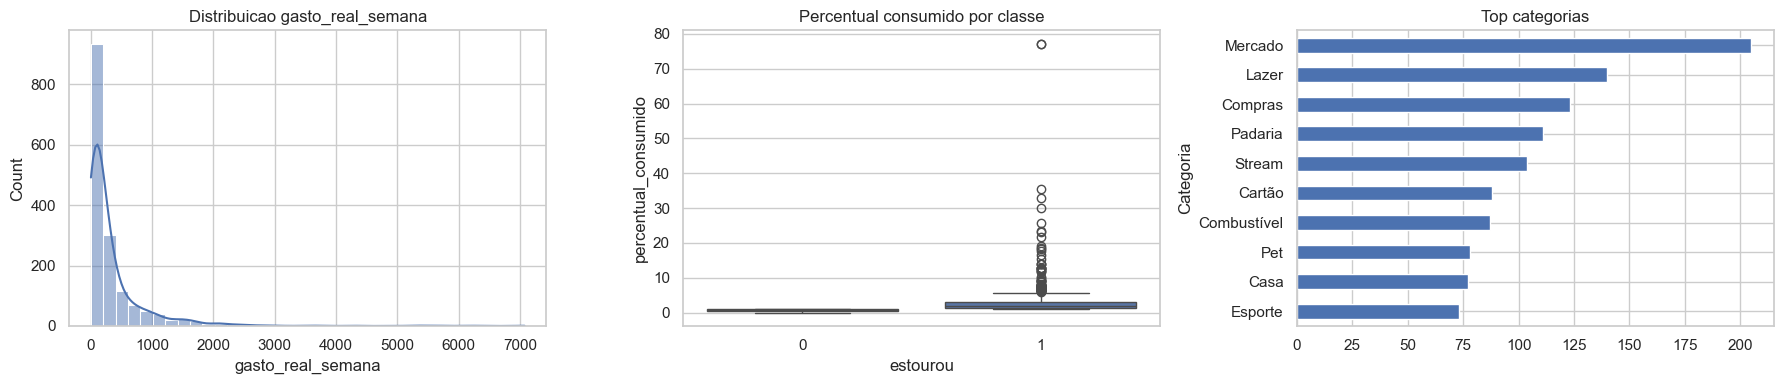

In [21]:
# EDA rapido
print('Shape final:', df.shape)
print('Taxa de estouro:', round(df['estourou'].mean(), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['gasto_real_semana'], bins=35, kde=True, ax=axes[0])
axes[0].set_title('Distribuicao gasto_real_semana')

sns.boxplot(data=df, x='estourou', y='percentual_consumido', ax=axes[1])
axes[1].set_title('Percentual consumido por classe')

(df['Categoria'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', ax=axes[2]))
axes[2].set_title('Top categorias')

plt.tight_layout()
plt.show()

## Modelagem de risco semanal (classificacao)

In [22]:
# Features para classificacao
feature_cols_num = [
    'gasto_real_semana', 'num_transacoes_semana', 'maior_transacao_semana',
    'media_transacao_semana', 'perc_fim_de_semana', 'expected_amount',
    'percentual_consumido', 'desvio_valor', 'week_number', 'is_recurring', 'confidence'
]
feature_cols_cat = ['Categoria', 'person', 'month_ref']

X = df[feature_cols_num + feature_cols_cat].copy()
y = df['estourou'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipe, feature_cols_num),
        ('cat', cat_pipe, feature_cols_cat),
    ]
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
}

results = []
fitted = {}

for name, model in models.items():
    clf = Pipeline(steps=[('prep', preprocess), ('model', model)])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
    })

    fitted[name] = (clf, pred)

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1
1,RandomForest,1.0000,1.000000,1.000000,1.00000
0,LogisticRegression,0.9575,0.987421,0.912791,0.94864


Melhor modelo por F1: RandomForest
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       228
           1      1.000     1.000     1.000       172

    accuracy                          1.000       400
   macro avg      1.000     1.000     1.000       400
weighted avg      1.000     1.000     1.000       400



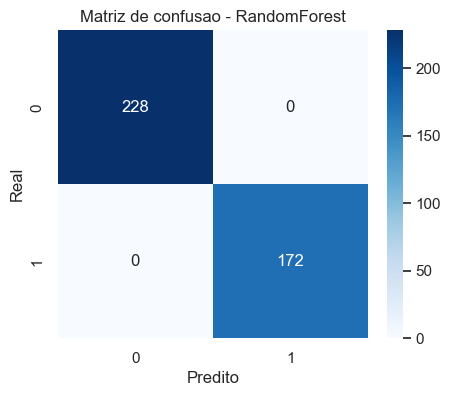

In [23]:
best_name = results_df.iloc[0]['model']
best_clf, best_pred = fitted[best_name]

print(f'Melhor modelo por F1: {best_name}')
print(classification_report(y_test, best_pred, digits=3))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusao - {best_name}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

## Segmentacao (clustering)
A segmentacao usa apenas atributos de comportamento, sem target.

Melhor K por silhouette: 2


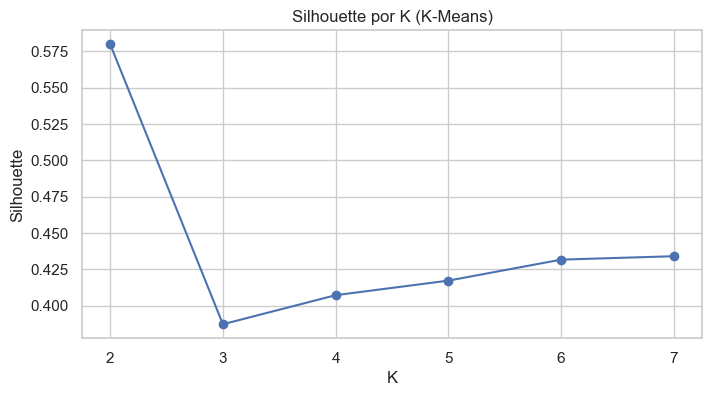

In [24]:
cluster_features = [
    'gasto_real_semana', 'num_transacoes_semana', 'maior_transacao_semana',
    'media_transacao_semana', 'perc_fim_de_semana', 'expected_amount',
    'percentual_consumido'
]

Xc = df[cluster_features].copy()
Xc = Xc.replace([np.inf, -np.inf], np.nan).fillna(Xc.median(numeric_only=True))

scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

k_values = range(2, 8)
sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15)
    labels = km.fit_predict(Xc_scaled)
    sil_scores.append(silhouette_score(Xc_scaled, labels))

best_k = list(k_values)[int(np.argmax(sil_scores))]
print('Melhor K por silhouette:', best_k)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), sil_scores, marker='o')
plt.title('Silhouette por K (K-Means)')
plt.xlabel('K')
plt.ylabel('Silhouette')
plt.show()

In [25]:
# Treina K-Means, Hierarquico e DBSCAN para comparacao
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=15)
df['cluster_kmeans'] = km.fit_predict(Xc_scaled)

agg = AgglomerativeClustering(n_clusters=best_k)
df['cluster_hier'] = agg.fit_predict(Xc_scaled)

db = DBSCAN(eps=0.9, min_samples=12)
df['cluster_dbscan'] = db.fit_predict(Xc_scaled)

def safe_sil(X, labels):
    n = len(set(labels)) - (1 if -1 in labels else 0)
    if n < 2:
        return np.nan
    return silhouette_score(X, labels)

compare = pd.DataFrame({
    'modelo': ['KMeans', 'Hierarquico', 'DBSCAN'],
    'n_clusters': [
        len(set(df['cluster_kmeans'])),
        len(set(df['cluster_hier'])),
        len(set(df['cluster_dbscan'])) - (1 if -1 in set(df['cluster_dbscan']) else 0),
    ],
    'silhouette': [
        safe_sil(Xc_scaled, df['cluster_kmeans']),
        safe_sil(Xc_scaled, df['cluster_hier']),
        safe_sil(Xc_scaled, df['cluster_dbscan']),
    ]
})
display(compare)

,modelo,n_clusters,silhouette
0,KMeans,2,0.579797
1,Hierarquico,2,0.679303
2,DBSCAN,2,0.319288


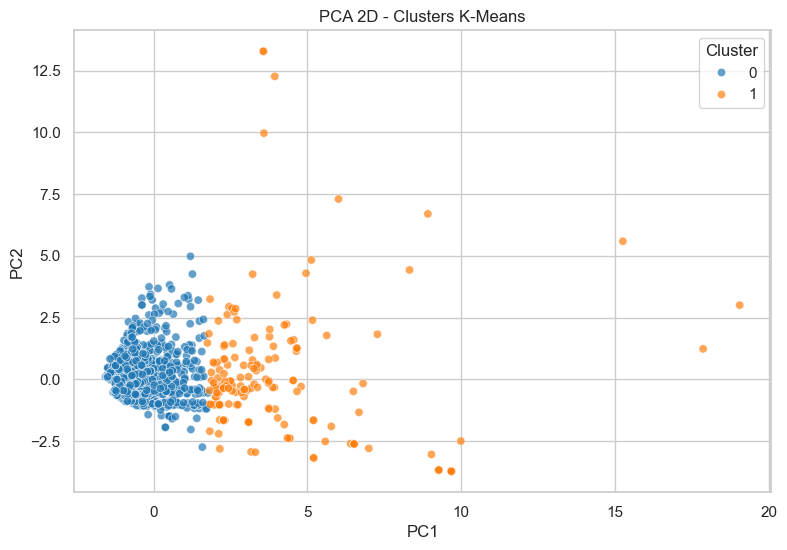

Variancia explicada PCA 2D: 0.6709


In [26]:
# Visualizacao PCA 2D dos clusters K-Means
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(Xc_scaled)
plot_df = pd.DataFrame({'PC1': pcs[:, 0], 'PC2': pcs[:, 1], 'cluster': df['cluster_kmeans']})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=0.7)
plt.title('PCA 2D - Clusters K-Means')
plt.legend(title='Cluster')
plt.show()

print('Variancia explicada PCA 2D:', pca.explained_variance_ratio_.sum().round(4))

,gasto_real_semana,num_transacoes_semana,maior_transacao_semana,media_transacao_semana,perc_fim_de_semana,expected_amount,percentual_consumido,taxa_estouro,categoria_dominante
cluster_kmeans,,,,,,,,,
0,194.45,2.02,131.43,105.62,0.26,188.83,1.37,0.398,Mercado
1,1506.35,3.12,1063.36,708.18,0.13,770.77,4.90,0.707,Casa


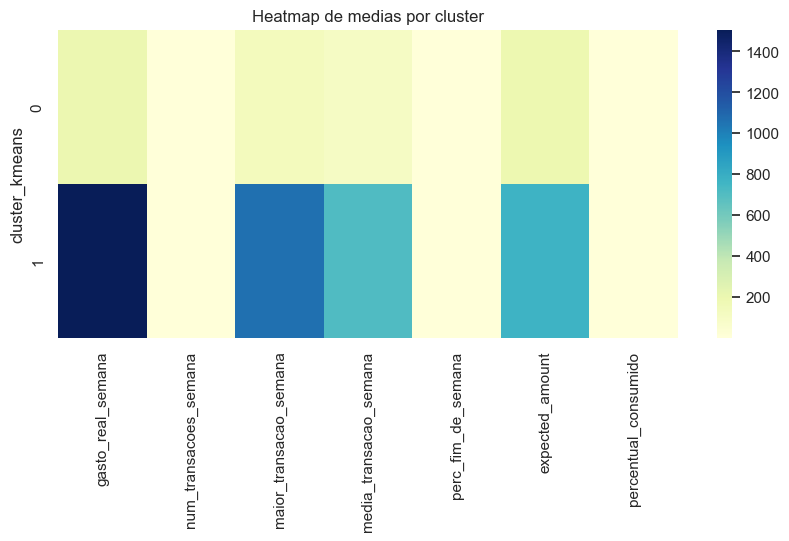

In [27]:
# Perfil de clusters (K-Means)
profile_num = df.groupby('cluster_kmeans')[cluster_features].mean().round(2)
profile_risk = df.groupby('cluster_kmeans')['estourou'].mean().round(3).rename('taxa_estouro')
profile_cat = (
    df.groupby(['cluster_kmeans', 'Categoria']).size()
      .reset_index(name='qtd')
      .sort_values(['cluster_kmeans', 'qtd'], ascending=[True, False])
      .groupby('cluster_kmeans').head(1)
      .set_index('cluster_kmeans')['Categoria']
      .rename('categoria_dominante')
)

profile = profile_num.join(profile_risk).join(profile_cat)
display(profile)

plt.figure(figsize=(10, 4))
sns.heatmap(profile_num, cmap='YlGnBu', annot=False)
plt.title('Heatmap de medias por cluster')
plt.show()

In [28]:
# Nomeacao automatica simples e recomendacoes
def nomear_cluster(row):
    if row['taxa_estouro'] >= 0.55:
        return 'Risco de Estouro'
    if row['percentual_consumido'] <= 0.75 and row['gasto_real_semana'] < row['expected_amount']:
        return 'Essencial Controlado'
    if row['maior_transacao_semana'] > profile['maior_transacao_semana'].median() * 1.25:
        return 'Alto Valor Planejado'
    return 'Lazer Volatil'

profile['nome_cluster'] = profile.apply(nomear_cluster, axis=1)

recomendacoes = {
    'Risco de Estouro': [
        'Definir teto semanal por categoria',
        'Ativar alerta quando consumo > 80% do orcamento',
        'Revisao semanal de transacoes fora do padrao'
    ],
    'Essencial Controlado': [
        'Manter estrategia atual de gastos',
        'Atualizar orcamentos com inflacao trimestral',
        'Monitorar apenas desvios relevantes'
    ],
    'Alto Valor Planejado': [
        'Planejar reserva para despesas de alto valor',
        'Criar calendario de pagamentos grandes',
        'Avaliar parcelamento com menor impacto semanal'
    ],
    'Lazer Volatil': [
        'Criar limite mensal para lazer',
        'Definir meta de reducao gradual',
        'Usar notificacao de gastos por fim de semana'
    ]
}

display(profile[['nome_cluster', 'taxa_estouro', 'categoria_dominante']])

for cid, row in profile.iterrows():
    nome = row['nome_cluster']
    print(f'Cluster {cid} - {nome}')
    for rec in recomendacoes.get(nome, []):
        print(f'  - {rec}')
    print('')

,nome_cluster,taxa_estouro,categoria_dominante
cluster_kmeans,,,
0,Lazer Volatil,0.398,Mercado
1,Risco de Estouro,0.707,Casa


Cluster 0 - Lazer Volatil
  - Criar limite mensal para lazer
  - Definir meta de reducao gradual
  - Usar notificacao de gastos por fim de semana

Cluster 1 - Risco de Estouro
  - Definir teto semanal por categoria
  - Ativar alerta quando consumo > 80% do orcamento
  - Revisao semanal de transacoes fora do padrao



## Conclusao

Checklist rapido:
- dados carregados e validados
- target de risco semanal construido
- baseline de classificacao comparado
- clustering comparado (K-Means, Hierarquico, DBSCAN)
- clusters perfilados e nomeados
- recomendacoes acionaveis geradas

Proximo passo sugerido: levar o `nome_cluster` e o `score de risco` para dashboard operacional.